# 1장 2강 실습: 데이터 분석 기초

In [1]:
import os
import pandas as pd
import kagglehub

# 1. 데이터셋 다운로드 및 경로 가져오기
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
csv_path = os.path.join(path, "dataset.csv")

# 2. 판다스로 깨끗하게 읽어오기
# 에러가 나지 않도록 구분자 자동 인식(sep=None) 기능을 사용합니다.
df = pd.read_csv(csv_path, sep=None, engine='python', encoding='utf-8')

# 3. 잘 불러와졌는지 데이터 확인하기
print("데이터 로드 성공! 전체 행/열 크기:", df.shape)
print(df.head())


c:\Users\bsis0\Documents\ax_study\04_ML_EXERCISE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


데이터 로드 성공! 전체 행/열 크기: (114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again    

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [3]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [4]:
print(df['artists'].mode())
print(df['track_name'].mode())
print(df['album_name'].mode())

mode_artists = df['artists'].mode()[0]
df.loc[:,'artists'] = df['artists'].fillna(mode_artists)

mode_track = df['track_name'].mode()[0]
df.loc[:,'track_name'] = df['track_name'].fillna(mode_track)

mode_album = df['album_name'].mode()[0]
df.loc[:,'album_name'] = df['album_name'].fillna(mode_album)

df.isnull().sum()


0    The Beatles
Name: artists, dtype: str
0    Run Rudolph Run
Name: track_name, dtype: str
0    Alternative Christmas 2022
Name: album_name, dtype: str


Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [5]:
print("TEMPO:\m", df['tempo'].describe())
print("POPULARITY:\n", df['popularity'].describe())

TEMPO:\m count    114000.000000
mean        122.147837
std          29.978197
min           0.000000
25%          99.218750
50%         122.017000
75%         140.071000
max         243.372000
Name: tempo, dtype: float64
POPULARITY:
 count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bsis0\AppData\Local\Temp\ipykernel_4292\860657125.py:1: SyntaxWarning: invalid escape sequence '\m'
  print("TEMPO:\m", df['tempo'].describe())


In [8]:
dups = df.duplicated().sum()

print("중복된 행의  개수:", dups)

중복된 행의  개수: 0


In [9]:
no_dups_df = df.drop_duplicates()
df2 = no_dups_df.reset_index(drop=True)
df2.describe()


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [14]:
outliers_df2 = df2[(df2['duration_ms']<0) & (df2['duration_ms']>1000000)]

# 참고 df[(df['나이'] >=30) & (df['점수'] >=80)]

In [15]:
outliers_df2.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
import matplotlib.pyplot as plt
import platform
from matplotlib import rc

os_name = platform.system()
if os_name == "Windows":
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")



In [22]:
df2.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

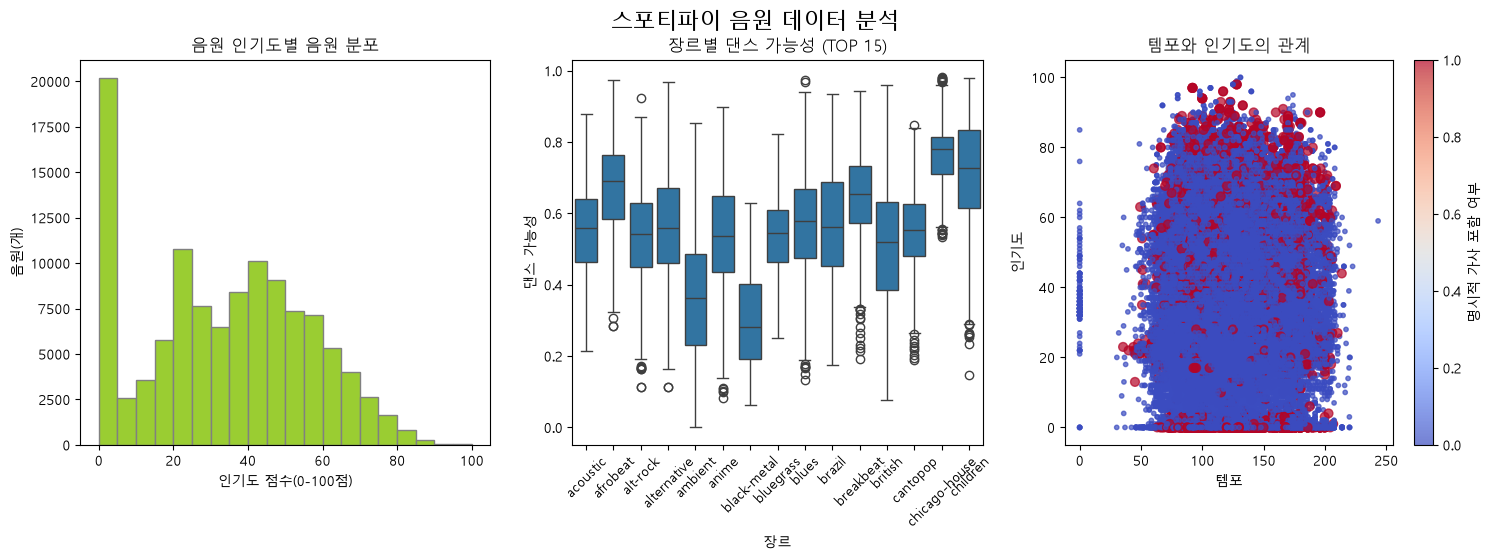

In [35]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("스포티파이 음원 데이터 분석", fontsize= 16)

# 히스토그램 - 음원의 인기도 분포
axes[0].hist(df2['popularity'], bins=20, color= 'yellowgreen', edgecolor='grey')
axes[0].set_title("음원 인기도별 음원 분포")
axes[0].set_xlabel('인기도 점수(0-100점)') # 점수 (0-100)
axes[0].set_ylabel('음원(개)') # 음원수

# 박스플롯(original ver.) - 장르별 댄스 가능성 분포
# sns.boxplot(x='track_genre', y='danceability', data=df2, ax=axes[1])
# axes[1].set_title('장르별 댄스 가능성')
# axes[1].set_xlabel('장르')
# axes[1].set_ylabel('댄스 가능성')

# 박스플롯(ver.2) - 장르별 댄스 가능성 분포
# sns.boxplot(
#     x='track_genre',
#     y='danceability',
#     data=df2,
#     ax=axes[1]
# )

# axes[1].set_title('장르별 댄스 가능성')
# axes[1].set_xlabel('장르')
# axes[1].set_ylabel('댄스 가능성')

# # x축 라벨 회전
# axes[1].tick_params(axis='x', rotation=90)

# 박스플롯(ver.3) - 장르별 댄스 가능성 분포
top_genres = df2['track_genre'].value_counts().head(15).index

df_top = df2[df2['track_genre'].isin(top_genres)]

sns.boxplot(
    x='track_genre',
    y='danceability',
    data=df_top,
    ax=axes[1]
)

axes[1].set_title('장르별 댄스 가능성 (TOP 15)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('댄스 가능성')
axes[1].tick_params(axis='x', rotation=45)


# 산점도 - 템포와 인기도의 관계도 
# (명시적 가사 포함 여부 변수 기준 점의 색상 다르게 설정 + 컬러바 추가)
scatter = axes[2].scatter(
    df2['tempo'],
    df2['popularity'],
    c=df2['explicit'],
    cmap='coolwarm',
    s=df2['explicit'] *30 + 10, # 0->10, 1->48
    alpha=0.7
)

axes[2].set_title('템포와 인기도의 관계')
axes[2].set_xlabel('템포')
axes[2].set_ylabel('인기도')

fig.colorbar(scatter, ax=axes[2], label= "명시적 가사 포함 여부")
